Step 0: Install required libraries (only in Colab)

In [4]:
!pip install -q timm
!pip install -q matplotlib opencv-python
!pip install -q gdown

Step 1: Import Required Libraries

In [5]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
import urllib.request
import os
import gdown

Definition: What is Monocular Depth Estimation?

      This is the task of predicting the depth (distance from camera)
      at each pixel in a single 2D RGB image using learned visual cues.

      MiDaS is a robust pretrained model that outputs relative depth maps.

Step 2: Load MiDaS Model from PyTorch Hub

In [6]:
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")  # lightweight version
midas.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
midas = midas.to(device)

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master


Loading weights:  None


Step 3: Load and Preprocess RGB Image

In [7]:
# Google Drive File ID
file_id = "1LeMMKtP-l05WE72jaqbT_vdztlC0oQoa"
download_url = f"https://drive.google.com/uc?id={file_id}"

# Download the image
image_path = "input_rgb.png"
gdown.download(download_url, image_path, quiet=False)

# Load and convert the image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
input_image = Image.fromarray(img)

# MiDaS transforms: Resize, normalize, convert to tensor
transform = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform

# Convert PIL Image to NumPy array before applying the transform
input_batch = transform(np.array(input_image)).to(device)

Downloading...
From: https://drive.google.com/uc?id=1LeMMKtP-l05WE72jaqbT_vdztlC0oQoa
To: /content/input_rgb.png
100%|██████████| 283k/283k [00:00<00:00, 4.55MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Step 4: Perform Depth Estimation

In [8]:
with torch.no_grad():
    prediction = midas(input_batch)
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

depth_map = prediction.cpu().numpy()

Step 5: Visualization of Results

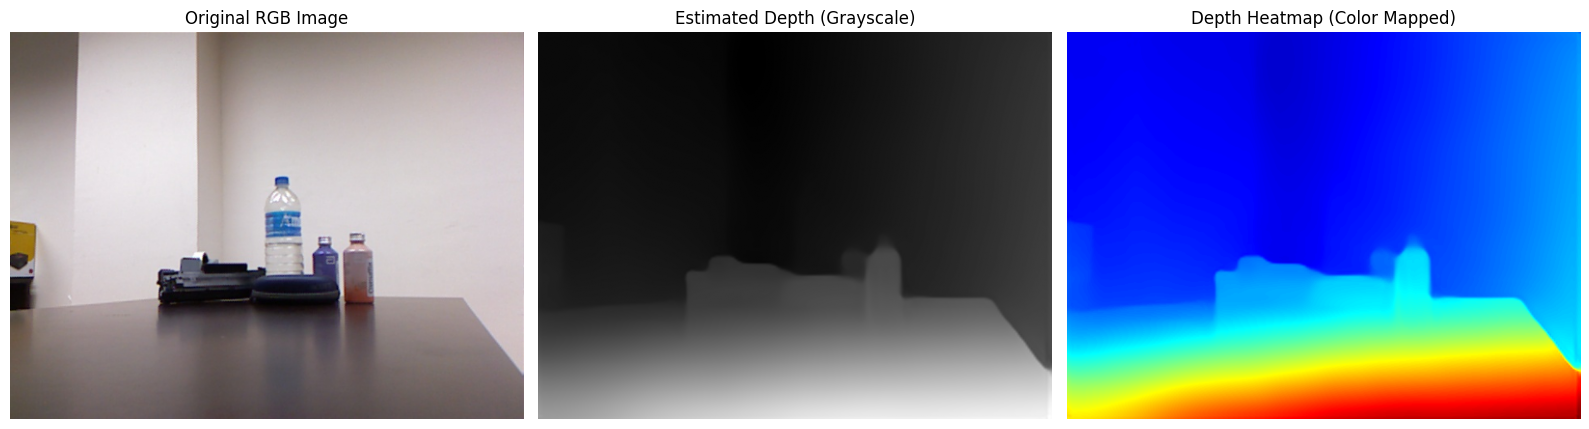

In [9]:
# Grayscale depth image
plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original RGB Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(depth_map, cmap='gray')
plt.title("Estimated Depth (Grayscale)")
plt.axis("off")

plt.subplot(1, 3, 3)
depth_heatmap = cv2.applyColorMap(cv2.convertScaleAbs(depth_map, alpha=255/depth_map.max()), cv2.COLORMAP_JET)
plt.imshow(cv2.cvtColor(depth_heatmap, cv2.COLOR_BGR2RGB))
plt.title("Depth Heatmap (Color Mapped)")
plt.axis("off")
plt.tight_layout()
plt.show()

Step 6: Depth Histogram

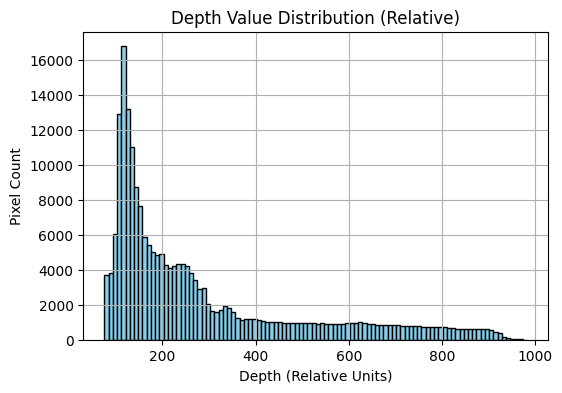

In [10]:
plt.figure(figsize=(6, 4))
plt.hist(depth_map.flatten(), bins=100, color='skyblue', edgecolor='black')
plt.title("Depth Value Distribution (Relative)")
plt.xlabel("Depth (Relative Units)")
plt.ylabel("Pixel Count")
plt.grid(True)
plt.show()

Step 7: Generate 3D Point Cloud from Depth

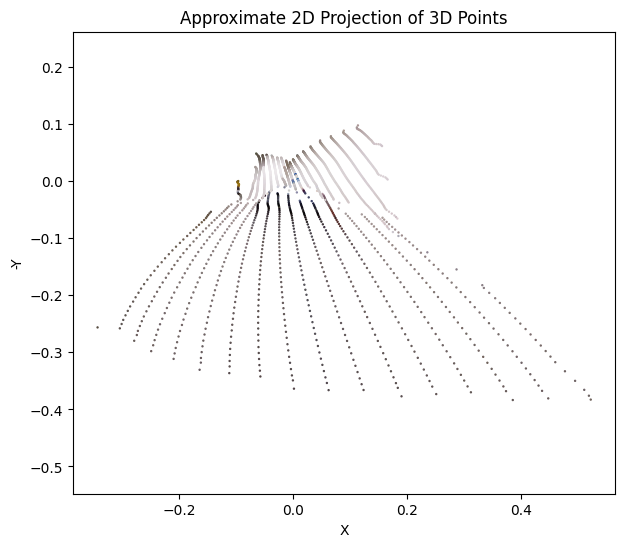

In [11]:
def generate_point_cloud(rgb, depth):
    h, w = depth.shape
    fx = fy = 500  # Focal length (in pixels, approx)
    cx, cy = w // 2, h // 2

    i, j = np.meshgrid(np.arange(w), np.arange(h), indexing='xy')
    z = depth / depth.max()  # Normalize depth
    x = (i - cx) * z / fx
    y = (j - cy) * z / fy

    xyz = np.stack((x, y, z), axis=-1).reshape(-1, 3)
    rgb = rgb.reshape(-1, 3)
    return xyz, rgb

xyz_pts, rgb_vals = generate_point_cloud(img, depth_map)

# Plot a sample point cloud (2D projection)
plt.figure(figsize=(7, 6))
plt.scatter(xyz_pts[::100, 0], -xyz_pts[::100, 1], c=rgb_vals[::100] / 255.0, s=0.5)
plt.title("Approximate 2D Projection of 3D Points")
plt.xlabel("X")
plt.ylabel("-Y")
plt.axis("equal")
plt.show()